C:\Users\Reinier.vandenAkker\AppData\Local\Temp\ipykernel_65252\2594969158.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stocks = yf.download("AAPL", period='10y')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2015-11-13,25.329182,26.057447,25.313399,25.974023,183249600
2015-11-16,25.744047,25.757575,25.027056,25.112733,152426800
2015-11-17,25.633562,25.940200,25.550138,25.910888,110467600
2015-11-18,26.445257,26.490350,26.041668,26.100290,186698800
2015-11-19,26.781200,26.999906,26.325754,26.524166,173183200
...,...,...,...,...,...
2025-11-07,268.209991,272.026299,266.511626,269.538690,48227400
2025-11-10,269.429993,273.730011,267.459991,268.959991,41312400
2025-11-11,275.250000,275.910004,269.799988,269.809998,46208300


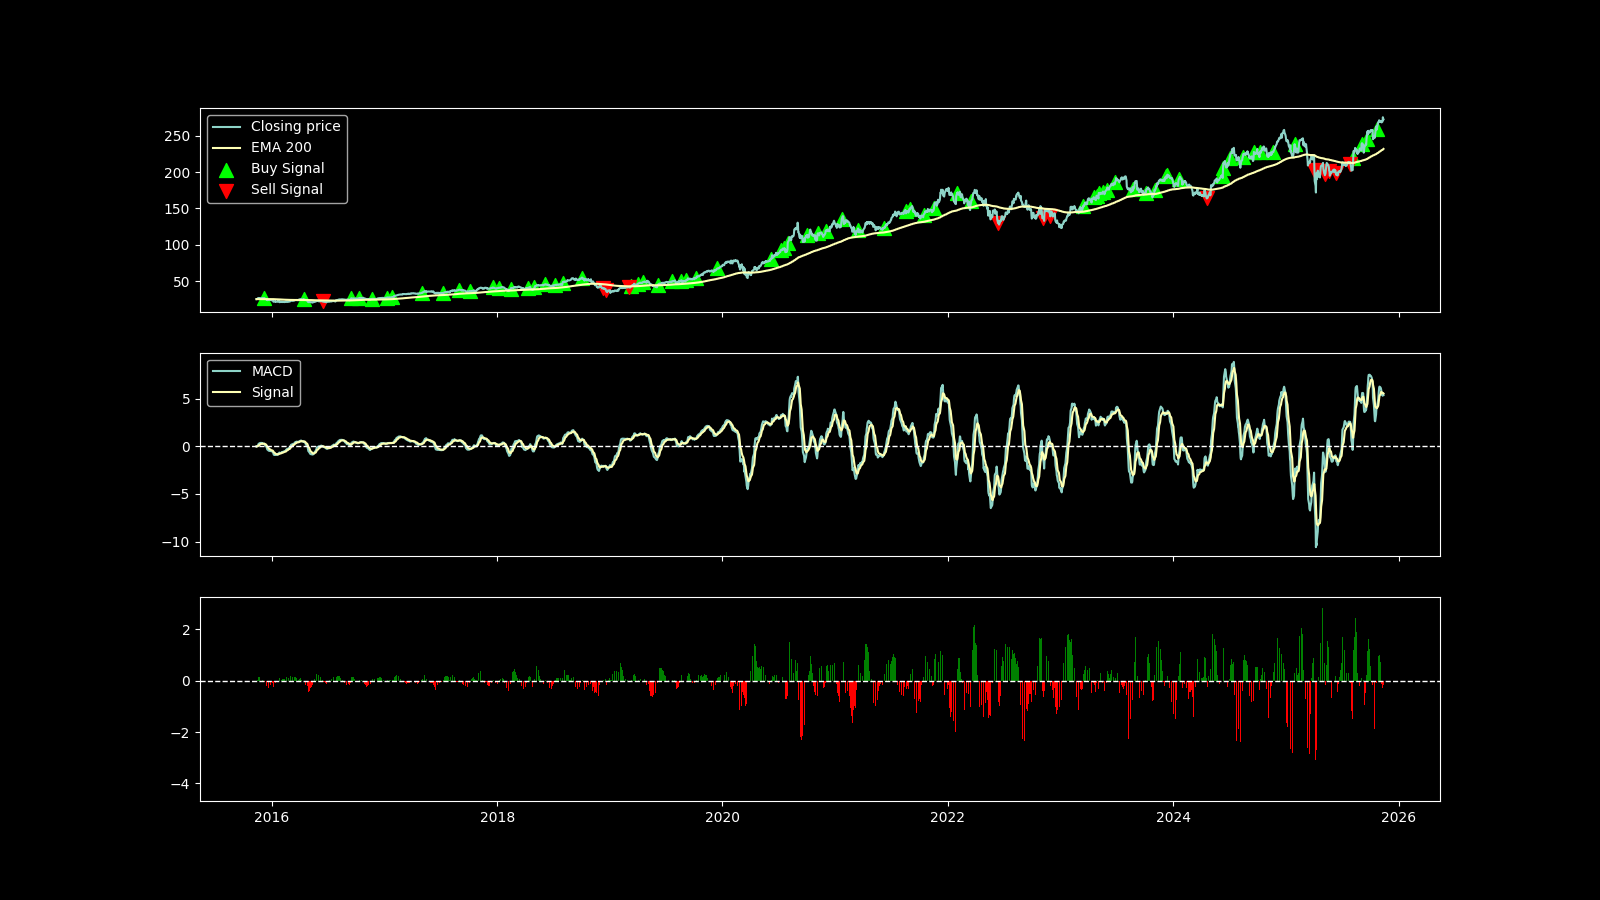

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf
%matplotlib widget


plt.style.use("dark_background")

short_window = 12
long_window = 26
signal_window = 9


#fetch stock data
stocks = yf.download("AAPL", period='10y')

df = pd.DataFrame(stocks)
df.columns = df.columns.droplevel(1)

display(df)

#calculate EMAs and MACDs
df['EMA12'] = df['Close'].ewm(span = short_window, adjust = False).mean()
df['EMA26'] = df['Close'].ewm(span = long_window, adjust = False).mean()
df['MACD'] = df['EMA12'] - df['EMA26']
df['Signal'] = df['MACD'].ewm(span=signal_window, adjust=False).mean()
df['hist_difference'] = df['MACD'] - df['Signal']
df['EMA200'] = df['Close'].ewm(span = 200, adjust = False).mean()
df['Trend_direction'] = np.where(df['Close'] > df['EMA200'], 'up', 'down')

# detect MACD crossovers: buy = MACD crosses above Signal
df['Buy_Signal'] = (df['MACD'].shift(1) < df['Signal'].shift(1)) & (df['MACD'] > df['Signal'])

# SELL = MACD kruist onder signal
df['Sell_Signal'] = (df['MACD'].shift(1) > df['Signal'].shift(1)) & (df['MACD'] < df['Signal'])
df['Buy_Signal']  = df['Buy_Signal']  & (df['Close'] > df['EMA200'])
df['Sell_Signal'] = df['Sell_Signal'] & (df['Close'] < df['EMA200'])



#plotting figures
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True, figsize=(16,9))

#Top plot
ax1.plot(df.index, df['Close'], label='Closing price')
ax1.plot(df.index, df['EMA200'], label='EMA 200')

# plot buy markers (groene driehoekjes)
# koopmomenten
ax1.scatter(df.loc[df['Buy_Signal']].index,
            df.loc[df['Buy_Signal'], 'Close'],
            marker='^', color='lime', s=100, label='Buy Signal')

# verkoopmomenten
ax1.scatter(df.loc[df['Sell_Signal']].index,
            df.loc[df['Sell_Signal'], 'Close'],
            marker='v', color='red', s=100, label='Sell Signal')

ax1.legend()



#Middle plot
ax2.plot(df['MACD'], label='MACD')
ax2.plot(df['Signal'], label='Signal')
ax2.legend()
ax2.axhline(0, color='white', linestyle='--', linewidth=1)

#bottom plot
ax3.plot()
ax3.bar(df.index, df['hist_difference'], color=['green' if h >= 0 else 'red' for h in df['hist_difference']], width=1)
ax3.axhline(0, color='white', linestyle='--', linewidth=1)



plt.show()